# Phase 1: Storage Matching — Moore Dam (1981)

**Goal:** Learn a set of bi-weekly reservoir operation parameters that minimize
the RMSE between simulated and mosartwmpy-observed storage at Moore Dam.

**Model:** Bi-weekly target-tracking policy (linear feedback control)
```
Q_release = Q_base[bw] + kS[bw] * (S_prev - S_target[bw]) + kQ[bw] * Q_inflow
```
- 104 parameters total (4 x 26 bi-weekly values)
- Optimized with Adam + gradient clipping, 20 random seeds

**Data:** mosartwmpy outputs for Moore Dam, 1981 (daily, MCM units)

In [5]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.nn as jnn


def find_project_root(start=None):
    # Find the project root by walking upward until the LM_26 package folder is found.
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "LM_26").is_dir():
            return path
    raise FileNotFoundError("Could not find project root containing the LM_26 folder.")


PROJECT_ROOT = find_project_root()
PACKAGE_DIR = PROJECT_ROOT / "LM_26"
INPUT_DIR = PACKAGE_DIR / "input_data_Moore"
OUTPUT_DIR = PACKAGE_DIR / "outputs_moore"
FIGURE_DIR = OUTPUT_DIR / "figures"
PARAM_DIR = OUTPUT_DIR / "best_params"

# Create output folders automatically if they do not already exist.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PARAM_DIR.mkdir(parents=True, exist_ok=True)

# Make local package imports work when running from VS Code, Jupyter, or repo root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from LM_26 import load_dam_data, run_multistart, run_scan, compute_metrics

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/liyingma/MEng_Project


## 1. Load Data

In [6]:
FILE_PATH = INPUT_DIR / "MooreDam_1981_tutorial_run_new.csv"

data, storage_obs, inflow, biweek_of_year, Smax = load_dam_data(FILE_PATH)

Loaded 365 days from: /Users/liyingma/MEng_Project/LM_26/input_data_Moore/MooreDam_1981_tutorial_run_new.csv
S0 = 243.50 MCM
Smax = 276.00 MCM  (proxy from observed max)
Mean inflow = 7.04 MCM/day


## 2. Quick Data Overview

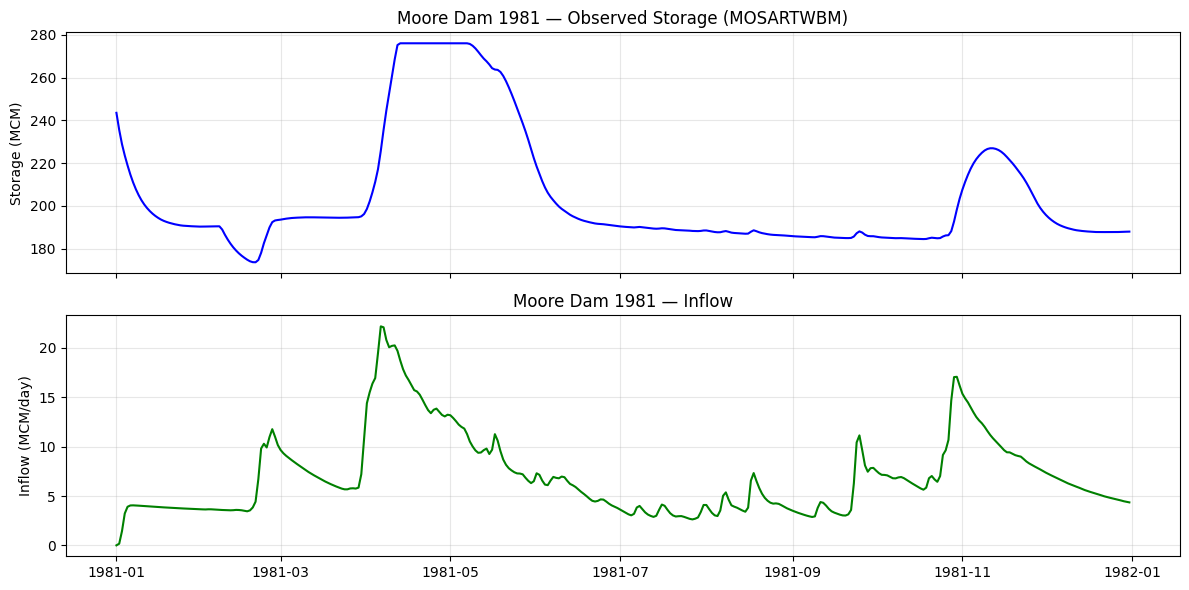

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(data['time'], np.array(storage_obs), color='blue', linewidth=1.5)
axes[0].set_ylabel('Storage (MCM)')
axes[0].set_title('Moore Dam 1981 — Observed Storage (MOSARTWBM)')
axes[0].grid(alpha=0.3)

axes[1].plot(data['time'], np.array(inflow), color='green', linewidth=1.5)
axes[1].set_ylabel('Inflow (MCM/day)')
axes[1].set_title('Moore Dam 1981 — Inflow')
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig(FIGURE_DIR / 'moore_dam_input_data.png', dpi=150)
plt.show()

## 3. Optimization (Multi-start Adam)

In [8]:
best_params, results, summary = run_multistart(
    inflow_data=inflow,
    storage_obs_data=storage_obs,
    biweek_data=biweek_of_year,
    Smax=Smax,
    num_runs=20,
    learning_rate=1e-2,
    num_iterations=20000,
    lam_smooth=0.02,
    tol=1e-3
)


===== Run 1/20 (seed=0) =====
Early stopping at iteration 5853 (best loss = 0.566608 at iter 4853)
Final loss: 0.566608
Final RMSE: 1.9871 MCM
Best iteration: 4853
Iterations run: 5854

===== Run 2/20 (seed=1) =====
Early stopping at iteration 6409 (best loss = 0.570061 at iter 5409)
Final loss: 0.570061
Final RMSE: 1.9887 MCM
Best iteration: 5409
Iterations run: 6410

===== Run 3/20 (seed=2) =====
Early stopping at iteration 7822 (best loss = 0.567538 at iter 6822)
Final loss: 0.567538
Final RMSE: 1.9791 MCM
Best iteration: 6822
Iterations run: 7823

===== Run 4/20 (seed=3) =====
Early stopping at iteration 6988 (best loss = 0.569382 at iter 5988)
Final loss: 0.569382
Final RMSE: 1.9908 MCM
Best iteration: 5988
Iterations run: 6989

===== Run 5/20 (seed=4) =====
Early stopping at iteration 4783 (best loss = 0.570987 at iter 3783)
Final loss: 0.570987
Final RMSE: 1.9994 MCM
Best iteration: 3783
Iterations run: 4784

===== Run 6/20 (seed=5) =====
Early stopping at iteration 5122 (best 

## 4. Save Best Parameters

In [9]:
np.save(PARAM_DIR / 'best_params_moore.npy', np.array(best_params))
print(f"Saved best_params_moore.npy  (best seed: {summary['best_seed']}, RMSE: {summary['min_rmse']:.4f} MCM)")

Saved best_params_moore.npy  (best seed: 10, RMSE: 1.9767 MCM)


## 5. Evaluate and Visualize

In [10]:
# Full simulation with best parameters
S_sim, Q_out = run_scan(
    inflow_data = inflow,
    initial_storage = storage_obs[0],
    biweek_data = biweek_of_year,
    params = best_params,
    Smax = Smax
)

metrics = compute_metrics(S_sim, storage_obs)
print(f"RMSE: {metrics['rmse']:.4f} MCM")
print(f"NSE: {metrics['nse']:.4f}  (1=perfect, <0=worse than mean)")
print(f"Bias: {metrics['bias_pct']:+.2f}%")

RMSE: 1.9832 MCM
NSE: 0.9951  (1=perfect, <0=worse than mean)
Bias: -0.07%


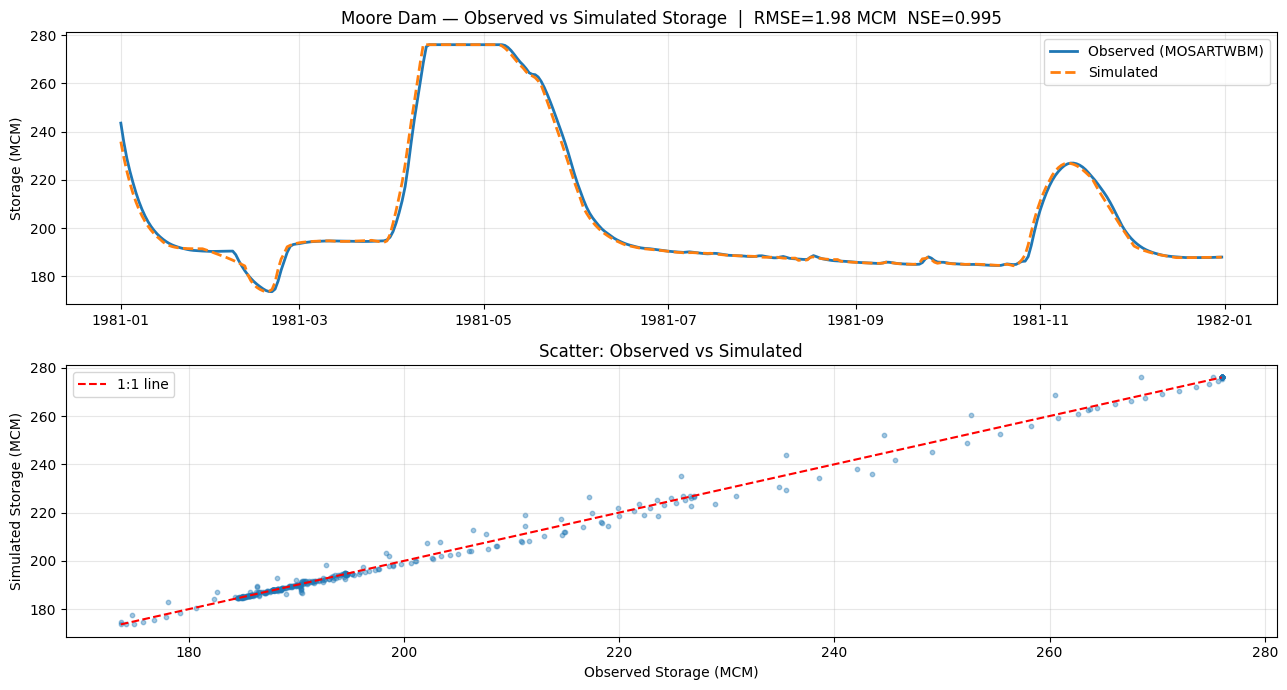

In [11]:
# Observed vs Simulated storage
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Time series
axes[0].plot(data['time'], np.array(storage_obs), label='Observed (MOSARTWBM)', linewidth=2)
axes[0].plot(data['time'], np.array(S_sim), label='Simulated', linestyle='--', linewidth=2)
axes[0].set_ylabel('Storage (MCM)')
axes[0].set_title(f'Moore Dam — Observed vs Simulated Storage  |  RMSE={metrics["rmse"]:.2f} MCM  NSE={metrics["nse"]:.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter plot (obs vs sim)
axes[1].scatter(np.array(storage_obs), np.array(S_sim), alpha=0.4, s=10)
lims = [float(storage_obs.min()), float(storage_obs.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='1:1 line')
axes[1].set_xlabel('Observed Storage (MCM)')
axes[1].set_ylabel('Simulated Storage (MCM)')
axes[1].set_title('Scatter: Observed vs Simulated')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig(FIGURE_DIR / 'moore_dam_storage_matching.png', dpi=150)
plt.show()

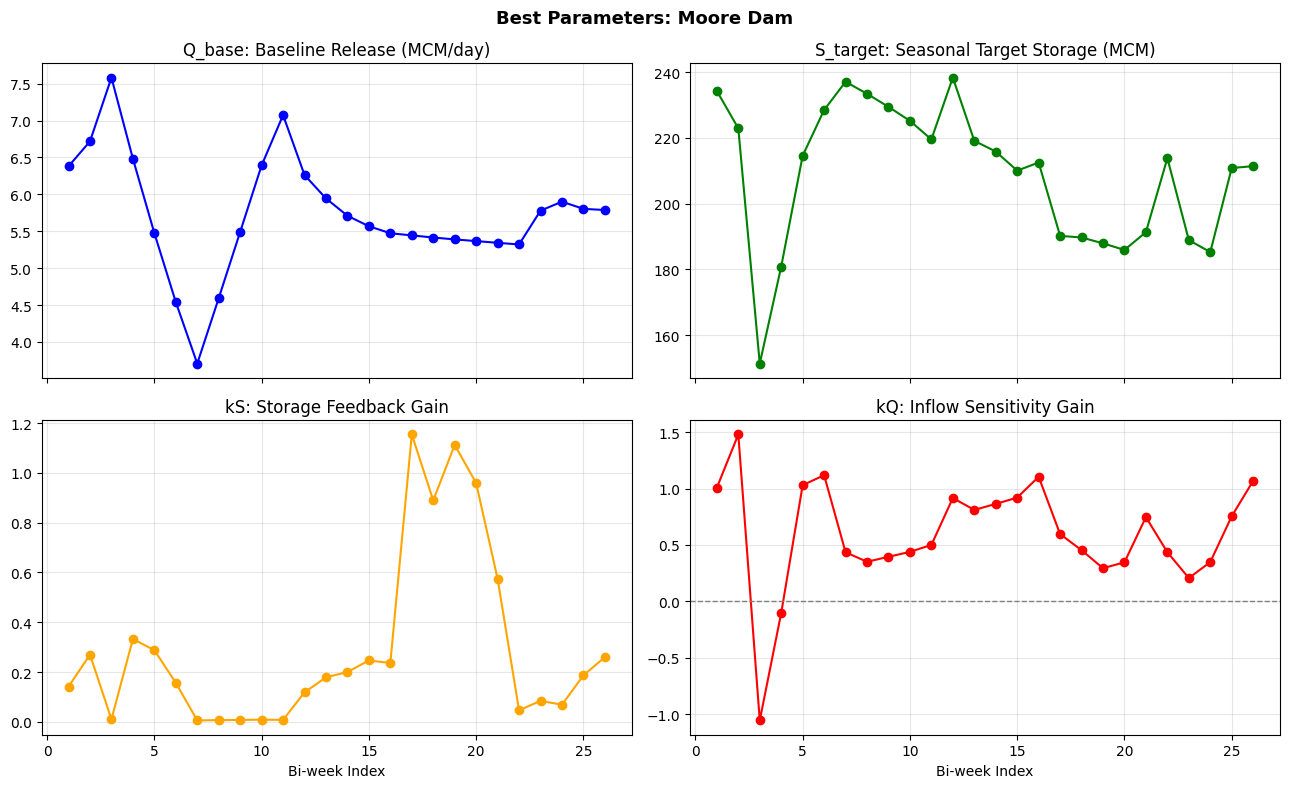

In [12]:
# Learned parameter curves
qbase_raw, starget_raw = best_params[0:26], best_params[26:52]
ks_raw, kq_raw = best_params[52:78], best_params[78:104]

Q_base = np.array(jnn.softplus(qbase_raw))
S_target = np.array(jnn.sigmoid(starget_raw)) * Smax
kS = np.array(jnn.softplus(ks_raw))
kQ = np.array(np.tanh(kq_raw)) * 2.0

biweeks = np.arange(1, 27)
fig, axs = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

axs[0,0].plot(biweeks, Q_base, 'o-', color='blue')
axs[0,0].set_title('Q_base: Baseline Release (MCM/day)')
axs[0,0].grid(alpha=0.3)

axs[0,1].plot(biweeks, S_target, 'o-', color='green')
axs[0,1].set_title('S_target: Seasonal Target Storage (MCM)')
axs[0,1].grid(alpha=0.3)

axs[1,0].plot(biweeks, kS, 'o-', color='orange')
axs[1,0].set_title('kS: Storage Feedback Gain')
axs[1,0].set_xlabel('Bi-week Index')
axs[1,0].grid(alpha=0.3)

axs[1,1].plot(biweeks, kQ, 'o-', color='red')
axs[1,1].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[1,1].set_title('kQ: Inflow Sensitivity Gain')
axs[1,1].set_xlabel('Bi-week Index')
axs[1,1].grid(alpha=0.3)

plt.suptitle('Best Parameters: Moore Dam', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig(FIGURE_DIR / 'moore_dam_learned_params.png', dpi=150)
plt.show()

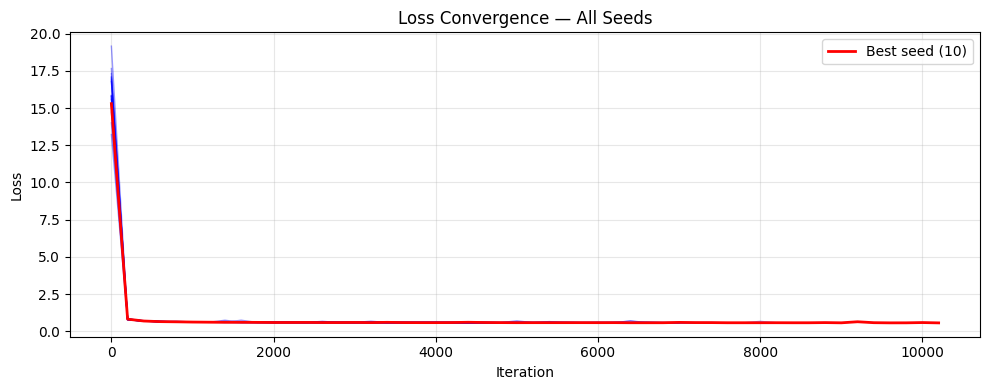

In [19]:
# Loss convergence across all seeds
plt.figure(figsize=(10, 4))
for r in results:
    iters = np.arange(len(r['loss_history']))*200
    plt.plot(iters, np.array(r['loss_history']), color='blue', alpha=0.4, linewidth=1)

# Highlight best seed
best = results[summary['best_seed']]
iters = np.arange(len(best['loss_history']))*200
plt.plot(iters, np.array(best['loss_history']), color='red', linewidth=2, label=f"Best seed ({summary['best_seed']})")

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Convergence — All Seeds')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig(FIGURE_DIR / 'moore_dam_loss_curves.png', dpi=150)
plt.show()

In [14]:
# collect all parameters
params_all = np.array([np.array(r["params_final"]) for r in results])  # shape: (n_runs, 104)

Q_base_all = params_all[:, 0:26]
S_target_all = params_all[:, 26:52]
kS_all = params_all[:, 52:78]
kQ_all = params_all[:, 78:104]

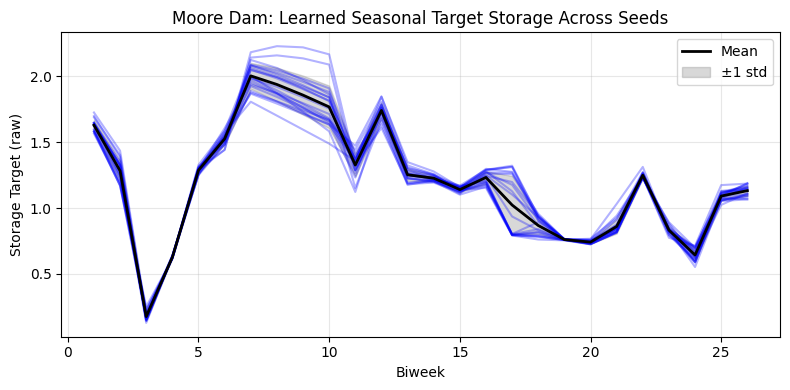

In [15]:
biweeks = np.arange(1, 27)
plt.figure(figsize=(8, 4))

# all seed
for i in range(S_target_all.shape[0]):
    plt.plot(biweeks, S_target_all[i], color='blue', alpha=0.3)

# mean
mean_curve = S_target_all.mean(axis=0)
plt.plot(biweeks, mean_curve, color='black', linewidth=2, label='Mean')

# std shading
std_curve = S_target_all.std(axis=0)
plt.fill_between(biweeks,
                 mean_curve - std_curve,
                 mean_curve + std_curve,
                 color='gray', alpha=0.3, label='±1 std')

plt.xlabel('Biweek')
plt.ylabel('Storage Target (raw)')
plt.title('Moore Dam: Learned Seasonal Target Storage Across Seeds')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()